In [5]:
!pip install -q --upgrade diffusers transformers accelerate

import torch, random
from diffusers import StableDiffusionPipeline
from IPython.display import display

# 1. 환경 및 장치 설정 (GPU 있으면 CUDA, 없으면 CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
print("Using device:", device)

# 2. 사전학습 모델 불러오기 (SD-Turbo)
model_id = "stabilityai/sd-turbo"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    variant="fp16" if device == "cuda" else None
)
pipe.to(device)

# 3. 이미지 생성 함수 정의
def generate_image(prompt, steps=4, guidance=0.0, seed=None):
    if seed is None:  # 시드값이 없으면 랜덤 설정
        seed = random.randint(0, 2**32 - 1)

    generator = torch.Generator(device=device).manual_seed(seed)

    # 이미지 생성
    result = pipe(
        prompt=prompt,
        num_inference_steps=steps,    # Turbo 모델은 1~4 스텝 권장
        guidance_scale=guidance,      # Turbo 모델은 0.0 권장
        generator=generator
    ).images[0]

    return result


Using device: cuda


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/4 [00:00<?, ?it/s]


Prompt: A cute dog wearing a spacesuit, highly detailed, 4k




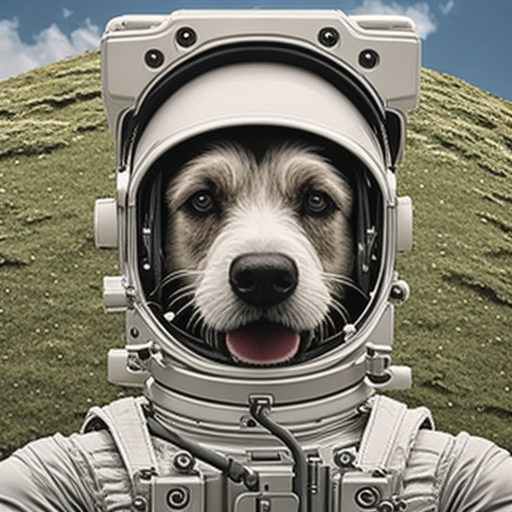

In [2]:
# 4. 이미지 생성 테스트
user_prompt = "A cute dog wearing a spacesuit, highly detailed, 4k"
image = generate_image(user_prompt)

print(f"\nPrompt: {user_prompt}\n\n")
display(image)
